# HCC-TACE-Seg → NPZ Conversion and Visualization

Converts the HCC-TACE-Seg dataset (DICOM + DICOM-SEG) into a unified `.npz` file.

**Dataset overview:**
- 105 HCC patients pre- (used 40 patient subset)
- Multiphasic contrast-enhanced CT
- 4 segments: Liver (1), Mass/Tumor (2), Portal vein (3), Abdominal aorta (4)
- Format: DICOM CT series + single DICOM-SEG file per patient

In [1]:
import sys
from pathlib import Path
import os
import numpy as np

parent = Path().resolve().parent.parent
if str(parent) not in sys.path:
    sys.path.append(str(parent))

from data.test_data.hcctase_to_npz import process_hcctase_dataset, OAR_MAPPING
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices

## 1. Process Dataset

For each patient:
1. Find the DICOM-SEG file (contains 4 segment channels)
2. Locate the referenced CT series
3. Resolve slice count mismatches (multi-phase CT vs single-phase SEG)
4. Crop to anatomy + resample to 1mm isotropic

In [2]:
data_dir = "HCCTase/hcc_tace_seg"
output_name = "HCCTase_ceCT"

if os.path.isdir(data_dir):
    process_hcctase_dataset(data_dir, output_name, margin=15)
else:
    print(f"Data directory '{data_dir}' not found. Please check the path.")


[1/40] Processing HCC_002 ...
  SEG segments: ['Liver', 'Mass', 'Portal vein', 'Abdominal aorta']
  SEG references CT series: ...4.291108858467809891631011685789
  Cropping to anatomy (margin=15) ...
  Resampling from ('2.500', '0.781', '0.781') -> 1.0 mm isotropic ...
  -> Final shape: (272, 366, 400)

[2/40] Processing HCC_006 ...
  SEG segments: ['Liver', 'Mass', 'Portal vein', 'Abdominal aorta']
  SEG references CT series: ...4.169644075146766664505907245033
  Cropping to anatomy (margin=15) ...
  Resampling from ('2.500', '0.781', '0.781') -> 1.0 mm isotropic ...
  -> Final shape: (172, 334, 399)

[3/40] Processing HCC_008 ...
  SEG segments: ['Liver', 'Mass', 'Portal vein', 'Abdominal aorta']
  SEG references CT series: ...4.225337061327095208867574560972
  Cropping to anatomy (margin=15) ...
  Resampling from ('2.500', '0.703', '0.703') -> 1.0 mm isotropic ...
  -> Final shape: (188, 342, 360)

[4/40] Processing HCC_010 ...
  SEG segments: ['Liver', 'Mass', 'Portal vein', 'Abdo

## 2. Load and Inspect

In [3]:
npz_path = Path(f"{output_name}.npz").resolve()

if os.path.exists(npz_path):
    dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
    all_ids = dg.dataloader.train_ids
    print(f"Loaded {len(all_ids)} patients")
    print(f"OAR mapping: {OAR_MAPPING}")
    
    sample_id = all_ids[0]
    img = dg.dataloader.dataset[sample_id]['image']
    mask = dg.dataloader.dataset[sample_id]['segmentations']
    
    print(f"\nSample: {sample_id}")
    print(f"Image shape: {img.shape}")
    unique_labels = np.unique(mask[0])
    print(f"Label IDs present: {unique_labels}")
    for label_name, label_id in OAR_MAPPING.items():
        vol = np.sum(mask[0] == label_id)
        print(f"  {label_id}: {label_name} — {vol:,} voxels")
else:
    print(f"Output file {npz_path} not found. Run cell above first.")


Loading NPZ dataset(s)…
Loaded 39 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\HCCTase_ceCT.npz

Final dataset size: 39 patients.

Loaded 39 patients
OAR mapping: {'Liver': 1, 'Mass': 2, 'Portal vein': 3, 'Abdominal aorta': 4}

Sample: HCCTase_ceCT_HCC_034
Image shape: (178, 327, 400)
Label IDs present: [0 1 2 3 4]
  1: Liver — 1,316,644 voxels
  2: Mass — 50,085 voxels
  3: Portal vein — 33,676 voxels
  4: Abdominal aorta — 8,323 voxels


## 3. Visualize

In [4]:
# Interactive view (not saved across restarts)

visualize_img_with_mask(img, mask[0])

interactive(children=(IntSlider(value=89, description='Slice:', max=177), Output()), _dom_classes=('widget-int…

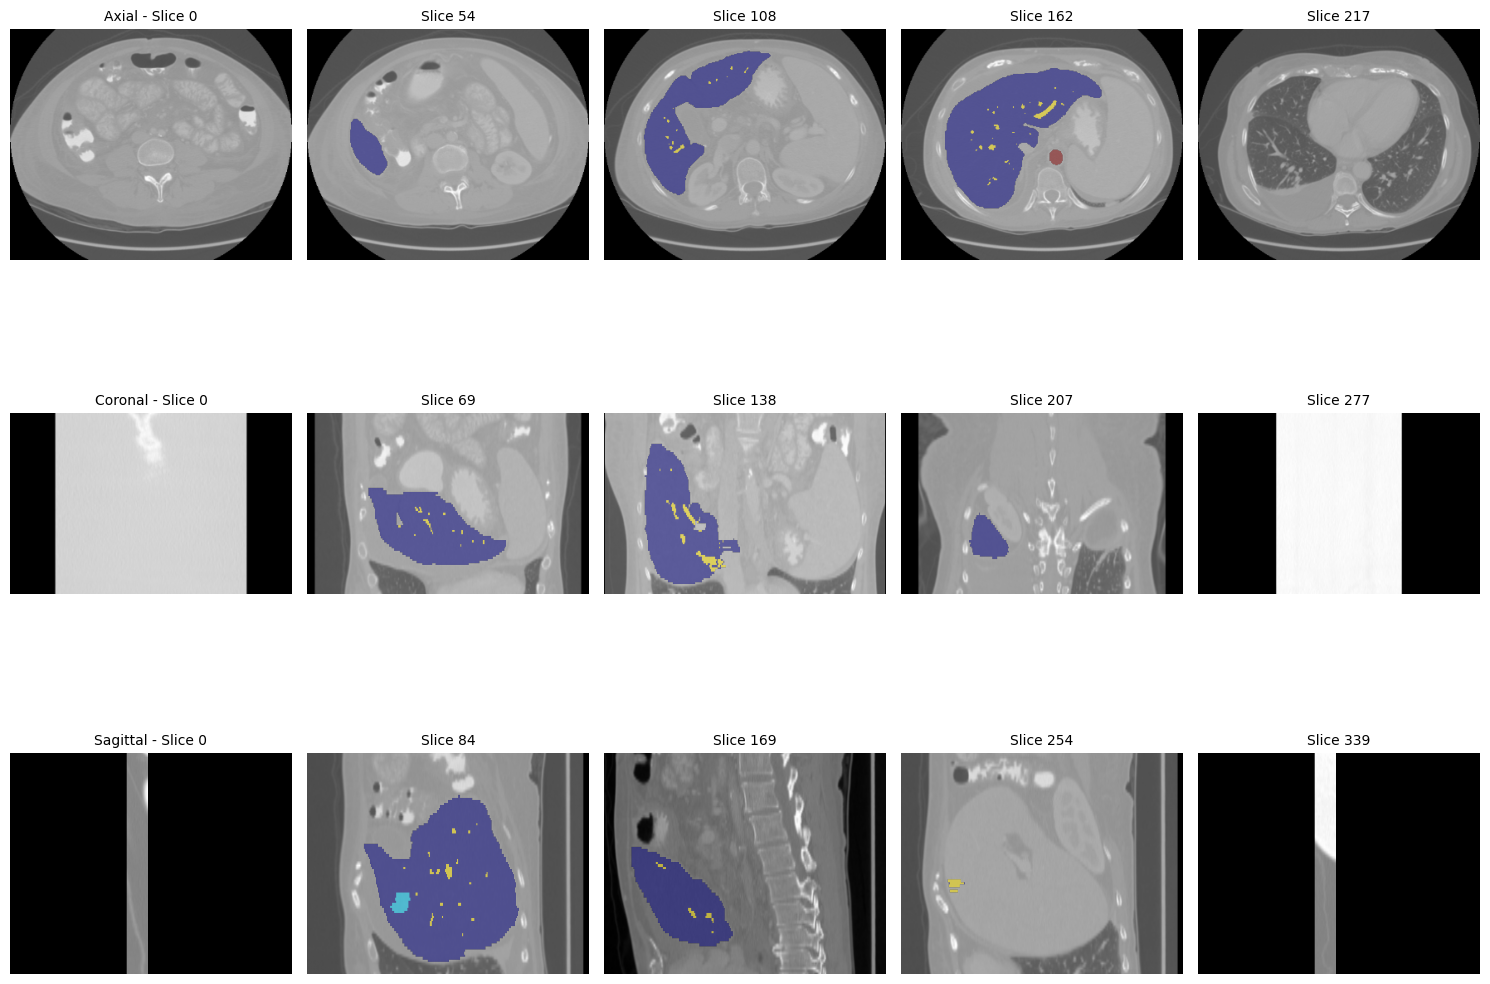

In [5]:
# Static persistent view (saved in notebook)
plot_vol_slices(img, mask[0])

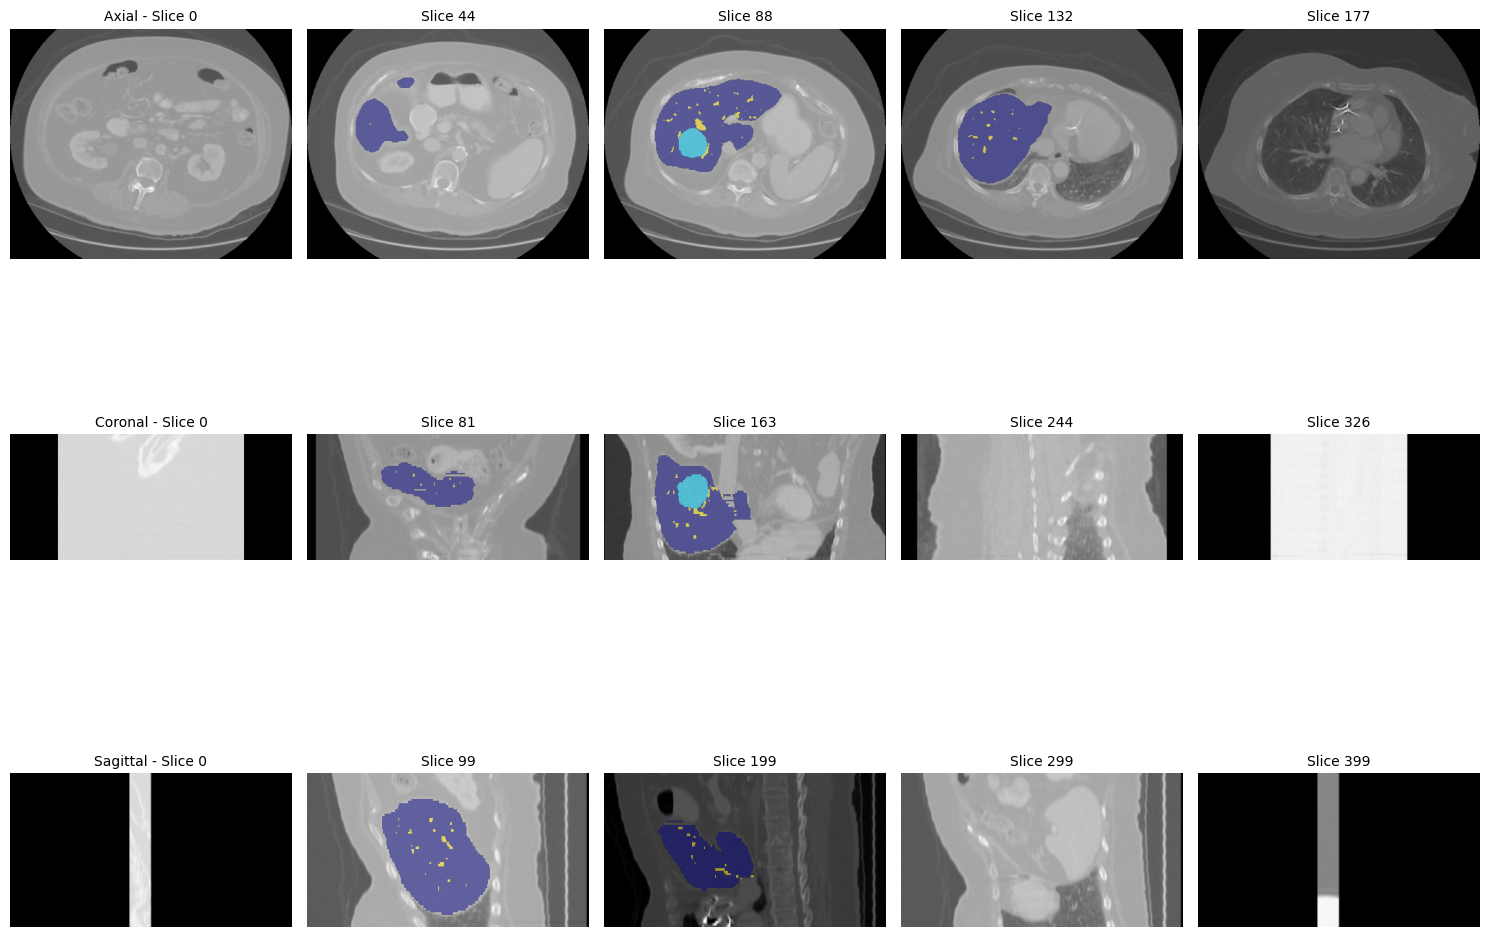

In [5]:
# Static persistent view (saved in notebook)
plot_vol_slices(img, mask[0])

## 4. Dataset Statistics

In [10]:
if os.path.exists(npz_path):
    shapes = []
    tumor_vols = []
    for pid in all_ids:
        img_i = dg.dataloader.dataset[pid]['image']
        mask_i = dg.dataloader.dataset[pid]['segmentations'][0]
        shapes.append(img_i.shape)
        tumor_vols.append(np.sum(mask_i == 2))  # Mass label
    
    z_sizes = [s[0] for s in shapes]
    print(f"Z-range: {min(z_sizes)} - {max(z_sizes)} slices")
    print(f"Tumor volume range: {min(tumor_vols):,} - {max(tumor_vols):,} voxels")
    print(f"Mean tumor volume: {np.mean(tumor_vols):,.0f} voxels (~{np.mean(tumor_vols)/1000:.1f} cm³ at 1mm iso)")

Z-range: 78 - 262 slices
Tumor volume range: 4,893 - 1,235,548 voxels
Mean tumor volume: 226,365 voxels (~226.4 cm³ at 1mm iso)
